<a href="https://colab.research.google.com/github/hagalaz-star/CV/blob/main/trailer_scene_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!jupyter nbconvert --to notebook --ClearOutputPreprocessor.enabled=True your_notebook.ipynb


[NbConvertApp] WARNING | pattern 'your_notebook.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
 

# Failure Analysis of Vision-Language Scene Retrieval for Robot Perception

In [2]:
# import subprocess
# from pathlib import Path

# TRAILER_DIR = Path("/content/drive/MyDrive/trailer_project")
# OUTPUT_DIR = Path("/content/drive/MyDrive/trailer_project/scenes")

# video_files = list(TRAILER_DIR.glob("*.mp4"))

# for video_path in video_files:
#     movie_name = video_path.stem
#     movie_output_dir = OUTPUT_DIR / movie_name
#     movie_output_dir.mkdir(parents=True, exist_ok=True)

#     cmd = [
#         "scenedetect",
#         "-i", str(video_path),
#         "-o", str(movie_output_dir),
#         "detect-adaptive",
#         "list-scenes",
#         "save-images",
#         "-n", "1"
#     ]

#     print(f"Processing: {movie_name}")
#     subprocess.run(cmd)

In [3]:
!pip install scenedetect[opencv] opencv-python

In [4]:
!git clone https://github.com/IDEA-Research/GroundingDINO.git
%cd GroundingDINO

!pip install -e .

!mkdir -p weights
!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth -P weights/

fatal: destination path 'GroundingDINO' already exists and is not an empty directory.
/content/GroundingDINO
Obtaining file:///content/GroundingDINO
  Preparing metadata (setup.py) ... done
  Running setup.py develop for groundingdino
    error: subprocess-exited-with-error
    
    × python setup.py develop did not run successfully.
    │ exit code: 1
    ╰─> See above for output.
    
    note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× python setup.py develop did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [5]:
from pathlib import Path

TRAILER_DIR = Path("/content/drive/MyDrive/trailer_project")
OUTPUT_DIR = Path("/content/drive/MyDrive/trailer_project/scenes")

In [6]:
from pathlib import Path
import os

for file in os.listdir(TRAILER_DIR):
    print(file)

Dune-Part-Three-Official-Trailer_720p.mp4
Interstellar-Trailer-Official_720p.mp4
BLADE-RUNNER-2049-Trailer_720p.mp4
Arrival-Trailer_720p.mp4
TENET-Final-Trailer_720p.mp4
scenes


In [7]:
!pip install transformers torch torchvision pillow tqdm pandas

clip 적용

In [8]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possibl

In [9]:
arrival_dir = Path("/content/drive/MyDrive/trailer_project/scenes/Arrival-Trailer_720p")
image_paths = sorted(list(arrival_dir.glob("*.jpg")))
print("Arrival keyframes:", len(image_paths))

Arrival keyframes: 110


In [10]:
from PIL import Image
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

img_path = image_paths[0]

image = Image.open(img_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    output = model.vision_model(pixel_values=inputs["pixel_values"])

print(type(output))

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>


CLIP의 vision encoder 출력 객체가 나온다. 설명하자면

CLIP 모델 내부에는 두 부분이 있다.

vision encoder  →  이미지를 벡터로 변환하는 부분

text encoder    →  텍스트를 벡터로 변환하는 부분

vision encoder가 이미지를 처리하고 나면 결과물을 객체 형태로 반환하는데, 그게 BaseModelOutputWithPooling

In [11]:
print(output.pooler_output.shape)

torch.Size([1, 768])


pooler_output은 CLIP vision model의 내부 출력

In [12]:
from PIL import Image
import torch
import numpy as np
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)
model.eval()

def extra_clip_embeddings(image_paths, model, processor, device):
  embeddings= []


  for image in image_paths:
    image = Image.open(image).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        # image_features= model.get_image_features(**inputs)
        output = model.vision_model(pixel_values=inputs["pixel_values"])
        image_features= model.visual_projection(output.pooler_output)

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    embeddings.append(image_features.cpu().numpy()[0])

  embeddings = np.array(embeddings).astype("float32")


  return embeddings



In [13]:
arrival_embeddings = extra_clip_embeddings(image_paths=image_paths, model=model, processor=processor, device=device)
print(arrival_embeddings.shape)

(110, 512)


In [14]:
print(type(arrival_embeddings))

<class 'numpy.ndarray'>


### BaseModelOutputWithPooling 은 최종 임베딩 벡터가 아니라 모델 출력 묶음 객체



In [15]:
print(len(image_paths))

110


In [16]:
len(image_paths) == arrival_embeddings.shape[0]

True

In [17]:
!pip install faiss-cpu






# 유사도 검사

In [18]:
import faiss
import numpy as np

vectors= arrival_embeddings.astype(np.float32)
faiss.normalize_L2(vectors)

In [19]:
print(vectors.shape)

(110, 512)


In [20]:
index = faiss.IndexFlatL2(512)
index.add(vectors)

In [21]:
print(index.ntotal)

110


In [22]:
query_vector = vectors[0:1]
D, I = index.search(query_vector, k=5)

# D가 작을수록 유사
print("유사도 점수:", D)
print("비슷한 이미지 인덱스:", I)

유사도 점수: [[0.         0.20263103 0.24230112 0.25883836 0.27021644]]
비슷한 이미지 인덱스: [[ 0 32 96 37 30]]


In [23]:
vectors_ip = vectors.copy()
faiss.normalize_L2(vectors_ip)

In [24]:
index_ip = faiss.IndexFlatIP(512)
index_ip.add(vectors_ip)

In [25]:
query_vector_ip = vectors_ip[0].reshape(1, -1)

## IP: 높을수록 유사
ip_D, ip_I = index_ip.search(query_vector_ip, k=5)

In [26]:
print("유사도 점수:", ip_D)
print("비슷한 이미지 인덱스:", ip_I)

유사도 점수: [[1.         0.89868456 0.8788495  0.8705809  0.8648919 ]]
비슷한 이미지 인덱스: [[ 0 32 96 37 30]]


# 검색 결과 시각화

In [27]:
import matplotlib.pyplot as plt
from PIL import Image


def search_show_image(query_idx, image_paths, vectors_ip, index_ip, k=5):
  query_vector = vectors_ip[query_idx: query_idx+1]
  scores, indices = index_ip.search(query_vector, k)

  plt.figure(figsize=(15,4))

  for i, idx in enumerate(indices[0]):
      image = Image.open(image_paths[idx]).convert('RGB')
      plt.subplot(1, k, i+1)
      plt.imshow(image)
      plt.axis("off")

      if idx == query_idx:
        plt.title("Query")

      else:
        plt.title("Result")

  plt.show()

  return scores, indices





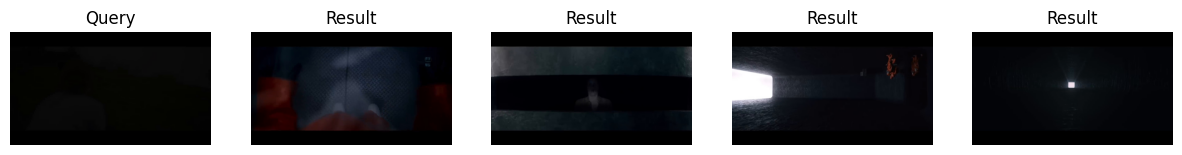

In [28]:
scores, indices = search_show_image(
    query_idx=0,
    image_paths=image_paths,
    vectors_ip=vectors_ip,
    index_ip=index_ip,
    k=5
)

결과 : 씬 분할 이미지 잘못 선정

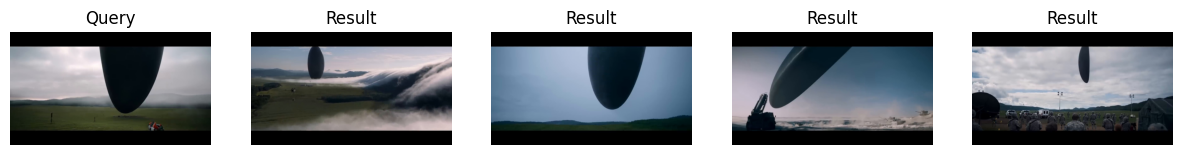

In [29]:
scores, indices = search_show_image(
    query_idx=25,
    image_paths=image_paths,
    vectors_ip=vectors_ip,
    index_ip=index_ip,
    k=5
)

전체 영화 트레일러 이미지로 유사도 찾아보기

In [30]:
from pathlib import Path

movie_dir = {
    "Arrival":Path("/content/drive/MyDrive/trailer_project/scenes/Arrival-Trailer_720p"),
    "Blade_runner":Path("/content/drive/MyDrive/trailer_project/scenes/BLADE-RUNNER-2049-Trailer_720p"),
    "Dune_part_three":Path("/content/drive/MyDrive/trailer_project/scenes/Dune-Part-Three-Official-Trailer_720p"),
    "Interstellar":Path("/content/drive/MyDrive/trailer_project/scenes/Interstellar-Trailer-Official_720p"),
    "Tenet":Path("/content/drive/MyDrive/trailer_project/scenes/TENET-Final-Trailer_720p"),
}

In [31]:
image_paths_by_movie = {}

all_image_paths = []
metadata = []

for movie_title, movie_path in movie_dir.items():
  image_paths = sorted(list(movie_path.glob("*.jpg")))
  image_paths_by_movie[movie_title] = image_paths

  print(movie_title, "keyframes:", len(image_paths))

  for idx, path in enumerate(image_paths):
    all_image_paths.append(path)
    metadata.append({
        "movie_title": movie_title,
        "keyframe_idx": idx,
        "image_path": str(path)
    })

Arrival keyframes: 110
Blade_runner keyframes: 80
Dune_part_three keyframes: 62
Interstellar keyframes: 78
Tenet keyframes: 120


In [32]:
print(len(all_image_paths))
print(len(metadata))

450
450


In [33]:
all_embeddings = extra_clip_embeddings(image_paths = all_image_paths, model= model, processor= processor, device =device)
print(all_embeddings.shape)

(450, 512)


In [34]:
all_vectors = all_embeddings.copy().astype("float32")
faiss.normalize_L2(all_vectors)

index_ip = faiss.IndexFlatIP(512)
index_ip.add(all_vectors)

print(index_ip.ntotal)

450


In [35]:
print(all_vectors.shape[0])

450


In [36]:
def search_cross_movie(query_idx, all_image_paths, metadata,  all_vectors, index_ip, k=5, search_k=30):
    query_vector = all_vectors[query_idx].reshape(1, -1)

    scores, indices = index_ip.search(query_vector, search_k)

    query_meta = metadata[query_idx]
    query_movie = query_meta["movie_title"]

    results = []

    for score, idx in zip(scores[0], indices[0]):
      result_meta = metadata[idx]

      # 자기 자신 제외
      if idx == query_idx:
        continue

      # 같은 영화 제외

      if result_meta["movie_title"] == query_movie:
        continue

      results.append((score, idx))

      if len(results) == k:
        break

    # 출력
    total_cols = len(results) + 1
    plt.figure(figsize=(4 * total_cols, 4))

    # Query 이미지
    plt.subplot(1, total_cols, 1)
    plt.imshow(Image.open(all_image_paths[query_idx]))
    plt.title(f"Query\n{query_meta['movie_title']}\nidx={query_idx}")
    plt.axis("off")

    # Result 이미지들
    for i, (score, idx) in enumerate(results, start=2):
        meta = metadata[idx]

        plt.subplot(1, total_cols, i)
        plt.imshow(Image.open(all_image_paths[idx]))
        plt.title(
            f"{meta['movie_title']}\n"
            f"keyframe={meta['keyframe_idx']}\n"
            f"score={score:.3f}"
        )
        plt.axis("off")


    plt.show()

    return results


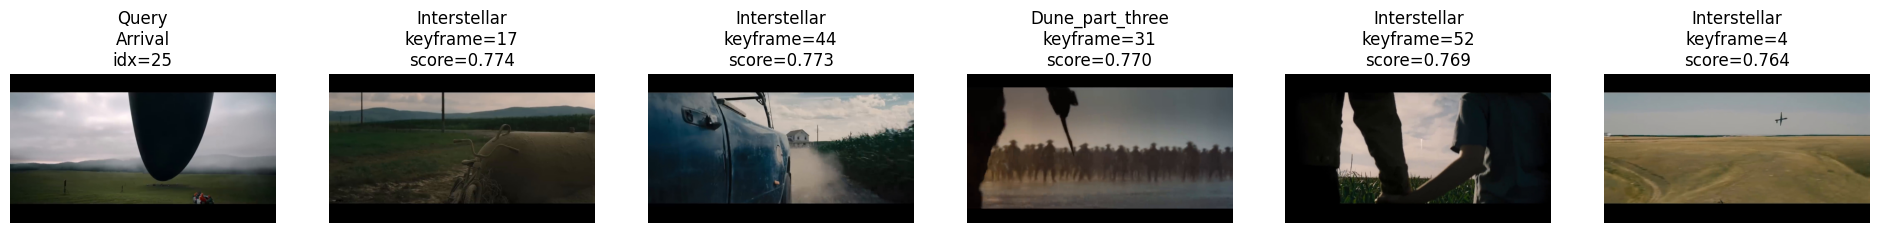

[(np.float32(0.7737803), np.int64(269)),
 (np.float32(0.7728533), np.int64(296)),
 (np.float32(0.7698039), np.int64(221)),
 (np.float32(0.7688297), np.int64(304)),
 (np.float32(0.76350784), np.int64(256))]

In [37]:
search_cross_movie(query_idx=25, all_image_paths = all_image_paths, metadata= metadata,  all_vectors=all_vectors, index_ip=index_ip, k=5, search_k=30)

In [38]:
print(metadata[0])
print(metadata[0].keys())

{'movie_title': 'Arrival', 'keyframe_idx': 0, 'image_path': '/content/drive/MyDrive/trailer_project/scenes/Arrival-Trailer_720p/Arrival-Trailer_720p-Scene-001-01.jpg'}
dict_keys(['movie_title', 'keyframe_idx', 'image_path'])


In [39]:
len(all_image_paths) == len(metadata) == len(all_vectors)

True

In [40]:
all_image_paths[25] == metadata[25]["image_path"]

False

In [41]:
print(np.linalg.norm(all_vectors[0]))
print(np.linalg.norm(all_vectors[25]))

1.0
1.0000001


1. "분위기는 비슷하지만 내용이 다른 프레임이 검색됨"

2. CLIP은 색감/조명 같은 visual feature에 강하게 반응하고, 객체나 행동 같은 semantic content는 상대적으로 약하게 인코딩함

3. CLIP만 단독으로 사용하는 대신, DINOv2나 ResNet처럼 시각적 형태와 구조를 더 잘 반영하는 모델과 함께 비교하면 객체 중심 유사도를 보완할 수 있다

결론 : CLIP 기반 retrieval은 전체 장면의 분위기와 의미적 유사성은 어느 정도 잡지만,

사용자가 기대하는 특정 객체의 형태나 시각적 핵심 요소는 놓칠 수 있다.

## 텍스트 검색 시각화


In [42]:
import torch

def extract_text_embedding(text, model, processor, device):
  model = model.to(device)
  model.eval()

  inputs = processor(
      text = [text],
      return_tensors="pt",
      padding=True,
      truncation=True,
  ).to(device)

  with torch.no_grad():
    text_outputs = model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )

    text_features = text_outputs.pooler_output
    text_features = model.text_projection(text_features)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

  text_vector = text_features.cpu().numpy().astype("float32")

  faiss.normalize_L2(text_vector)

  print(type(text_features))
  print(text_features.shape)
  print(text_features[0][:10])

  return text_vector

In [43]:
def search_text_scene(text_query, index_ip, metadata, model, processor, device, all_image_paths, k=5, search_k=30, exclude_movie=None):
      text_vector = extract_text_embedding(text_query, model, processor, device)

      scores, indices = index_ip.search(text_vector, search_k)

      results =[]

      for score, idx in zip(scores[0], indices[0]):
          result_meta = metadata[idx]

          if exclude_movie is not None and result_meta["movie_title"] == exclude_movie:
            continue

          results.append((score, idx))

          if len(results) ==k:
            break

      total_cols = len(results)
      plt.figure(figsize=(4 * total_cols, 4))


      for i, (score, idx) in enumerate(results, start=1):
          img = Image.open(all_image_paths[idx])
          meta = metadata[idx]

          movie_title = meta["movie_title"]
          keyframe_idx = meta["keyframe_idx"]


          plt.subplot(1, k, i)
          plt.imshow(img)
          plt.axis("off")
          plt.title(
              f"{movie_title}\nkeyframe {keyframe_idx}\nscore {score:.3f}",
              fontsize=10
          )

      plt.tight_layout()
      plt.show()

      return results



<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([ 0.0376,  0.0254, -0.0344,  0.0059,  0.0254,  0.0250, -0.0638, -0.0498,
         0.0606,  0.0455], device='cuda:0')


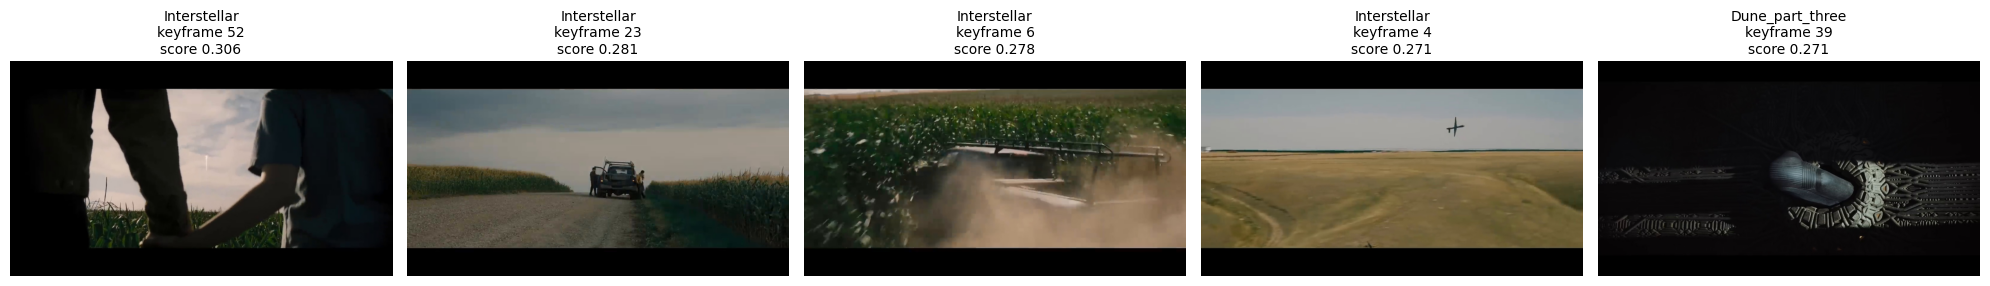

[(np.float32(0.30646023), np.int64(304)),
 (np.float32(0.281218), np.int64(275)),
 (np.float32(0.27841866), np.int64(258)),
 (np.float32(0.27124494), np.int64(256)),
 (np.float32(0.2709266), np.int64(229))]

In [44]:
search_text_scene(
                  text_query="a giant black alien object over a field",
                  index_ip= index_ip,
                  metadata= metadata,
                  model=model,
                  processor= processor,
                  device= device,
                  all_image_paths=all_image_paths,
                  k=5,
                  search_k=30,
                  exclude_movie= "Arrival"
  )

Arrival을 제외한 상태에서 Arrival 고유 장면을 설명하는 텍스트 쿼리를 입력했을 때, 검색 결과는 실제의미와 맞지않는 장면을 반환했다.

이는 데이터셋 내에  해당장면과 대응하는 시각적인 후보가 없을 경우,

CLIP 은 전체 문장 의미보다 field, dark tone, sci-fi object 같은 부분

단서에 기반해 검색했다.



In [45]:
# 의미없는 매개변수 exclude_movie 지우고  max_per_movie 넣기

def search_text_scene(text_query, index_ip, metadata, model, processor, device, all_image_paths, k=5, search_k=30, max_per_movie=None):
  text_vector = extract_text_embedding(text_query, model, processor, device)

  scores, indices = index_ip.search(text_vector, search_k)

  results= []
  movie_count = {}

  for score , idx in zip(scores[0], indices[0]):
      result_meta = metadata[idx]
      movie_title = result_meta["movie_title"]

      if max_per_movie is not None and movie_count.get(movie_title, 0) >= max_per_movie:
        continue


      results.append((score, idx))
      movie_count[movie_title] = movie_count.get(movie_title, 0) + 1

      if len(results) == k:
        break


  plt.figure(figsize=(4 * len(results), 4))

  for i,(score, idx) in enumerate(results, start=1):
      img = Image.open(all_image_paths[idx])
      meta = metadata[idx]

      plt.subplot(1, len(results), i)
      plt.imshow(img)
      plt.axis("off")
      plt.title(
              f"{meta['movie_title']}\n"
              f"keyframe {meta['keyframe_idx']}\n"
              f"score {score:.3f}"
          )

  plt.show()


  return results


<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([ 0.0376,  0.0254, -0.0344,  0.0059,  0.0254,  0.0250, -0.0638, -0.0498,
         0.0606,  0.0455], device='cuda:0')


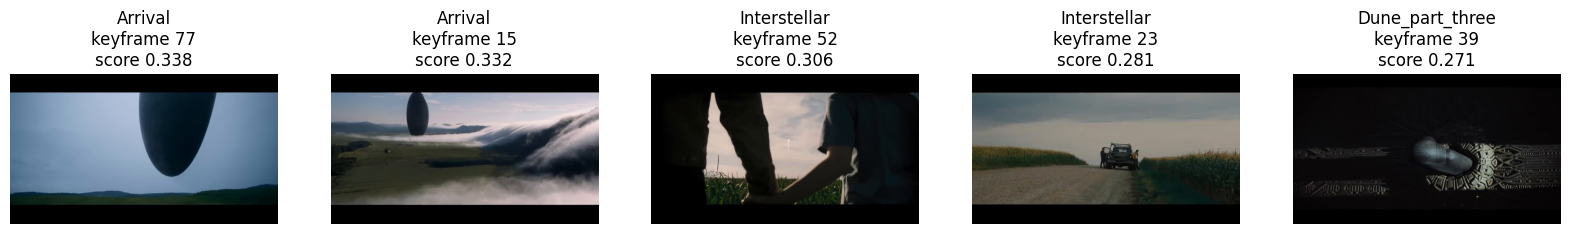

[(np.float32(0.33772352), np.int64(77)),
 (np.float32(0.33193272), np.int64(15)),
 (np.float32(0.30646023), np.int64(304)),
 (np.float32(0.281218), np.int64(275)),
 (np.float32(0.2709266), np.int64(229))]

In [46]:
search_text_scene(
                  text_query="a giant black alien object over a field",
                  index_ip= index_ip,
                  metadata= metadata,
                  model=model,
                  processor= processor,
                  device= device,
                  all_image_paths=all_image_paths,
                  k=5,
                  search_k=30,
                  max_per_movie=2
  )

In [47]:
import inspect

print(inspect.signature(search_text_scene))

(text_query, index_ip, metadata, model, processor, device, all_image_paths, k=5, search_k=30, max_per_movie=None)


In [48]:
pip install umap-learn


In [49]:
!pip install -q umap-learn gradio plotly

In [50]:


# reducer = umap.UMAP(
#     n_neighbors=15,
#     min_dist = 0.1,
#     n_components=2,
#     metric ='cosine',
#     random_state=42

# )
# embedding = reducer.fit_transform(vectors_ip)
# embedding.shape


In [51]:
import umap
import plotly.express as px
import umap.umap_ as umap
import pandas as pd


def visualize_umap(n_neighbors=15, min_dist=0.1, color_by="movie_title"):
  reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist = min_dist,
    n_components=2,
    metric ='cosine',
    random_state=42

)
  embedding = reducer.fit_transform(all_vectors)


  df = pd.DataFrame({
      "x":embedding[:, 0],
      "y":embedding[:, 1],
      "movie_title": [meta["movie_title"] for meta in metadata],
      "keyframe_idx": [meta["keyframe_idx"] for meta in metadata],
      "image_path": [meta["image_path"] for meta in metadata]
  })

  fig = px.scatter(
        df,
        x="x",
        y="y",
        color=color_by,
        hover_data=["movie_title", "keyframe_idx", "image_path"],
        title="UMAP Visualization of CLIP Keyframe Embeddings"
    )

  return fig





In [52]:
print(vectors_ip.shape)
print(len(metadata))
print(type(vectors_ip))
print(metadata[0])

(110, 512)
450
<class 'numpy.ndarray'>
{'movie_title': 'Arrival', 'keyframe_idx': 0, 'image_path': '/content/drive/MyDrive/trailer_project/scenes/Arrival-Trailer_720p/Arrival-Trailer_720p-Scene-001-01.jpg'}


In [53]:
embedding = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
).fit_transform(vectors_ip)


print("embedding 길이:", embedding.shape[0])
print("metadata 길이:", len(metadata))
print("vectors_ip 길이:", vectors_ip.shape[0])

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


embedding 길이: 110
metadata 길이: 450
vectors_ip 길이: 110


In [54]:
import gradio as gr

demo =  gr.Interface(
    fn=visualize_umap,
    inputs=[
            gr.Slider(2, 50, value=15, step=1, label= "n_neighbors"),
            gr.Slider(0.0,1.0, value=0.1, step=0.05, label="min_dist"),
            gr.Dropdown(
                choices =["movie_title", "keyframe_idx"], value="movie_title", label="Color by")],

    outputs=gr.Plot(),
    flagging_mode="never"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9c8c40f8cbc6c54b00.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [55]:
fig = visualize_umap(15, 0.1, "movie_title")
fig.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


movie_title 라벨 시각화는 각 키프레임을 영화별 색상으로 구분하고, CLIP 임베딩을 기준으로 시각적으로 유사한 키프레임들이 2차원 공간에 어떻게 분포하는지 보여준다. 가까운 점들은 시각적으로 유사한 장면으로 해석할 수 있고, 서로 다른 영화의 점들이 섞여 있다면 영화가 달라도 유사한 장면들이 존재한다는 의미이다.


keyframe_idx 라벨 시각화는 각 키프레임이 트레일러 안에서 몇 번째 장면인지 색상으로 구분하고, CLIP 임베딩을 기준으로 시각적으로 유사한 키프레임들이 2차원 공간에 어떻게 분포하는지 보여준다.

가까운 점들은 순서와 관계없이 시각적으로 유사한 장면으로 해석할 수 있으며, 색상이 연속적으로 이어지지 않는다면 트레일러의 시간 순서와 시각적 유사도가 반드시 일치하지 않는다는 의미이다.

# 검색 결과 평가 및 실패 사례 분석

<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([-0.0154, -0.0027, -0.0184, -0.0022, -0.0012, -0.0211,  0.0075, -0.0570,
        -0.0066,  0.0339], device='cuda:0')


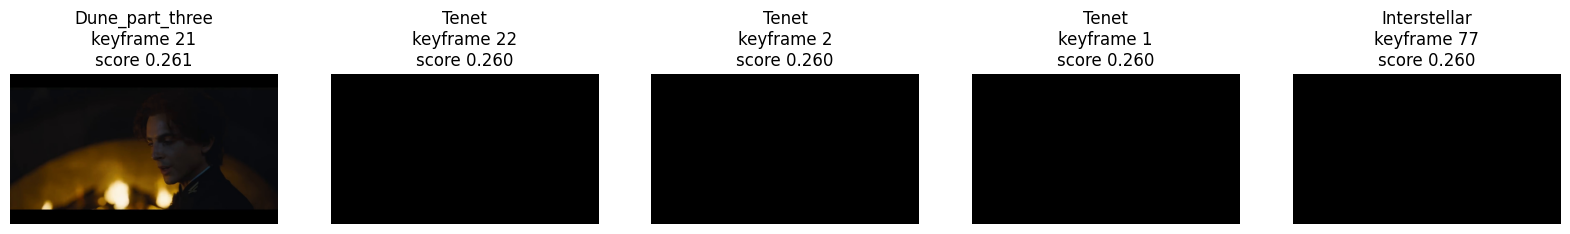

[(np.float32(0.26064193), np.int64(211)),
 (np.float32(0.2603034), np.int64(352)),
 (np.float32(0.2603034), np.int64(332)),
 (np.float32(0.2603034), np.int64(331)),
 (np.float32(0.2603034), np.int64(329))]

In [56]:
search_text_scene(
                  text_query="a close-up face in a dark room",
                  index_ip= index_ip,
                  metadata= metadata,
                  model=model,
                  processor= processor,
                  device= device,
                  all_image_paths=all_image_paths,
                  k=5,
                  search_k=30,
                  max_per_movie=None
  )

## 텍스트-이미지 검색 결과 평가 기준 및 실패 유형 분류

---

본 실험에서는 총 7개의 텍스트 쿼리 결과를 분석하였다.
검색 결과는 먼저 `Good`, `Partial`, `Fail`로 평가하고, 실패 사례는 모델이 어떤 시각 단서를 잘못 해석했는지에 따라 4가지 유형으로 분류하였다.

---

## 1. 평가 기준

---

| 평가        | 기준                             |
| --------- | ------------------------------ |
| `Good`    | 쿼리의 핵심 객체와 장면 구성이 대부분 맞는 경우    |
| `Partial` | 분위기나 일부 객체는 맞지만, 세부 의미가 애매한 경우 |
| `Fail`    | 쿼리와 시각적으로 거의 관련이 없는 경우         |

---

## 2. 텍스트-이미지 검색 실패 유형 분류

---

### 1. Object Failure

---

쿼리에서 가장 중요한 핵심 물체를 제대로 찾지 못한 경우이다.

예를 들어 `cup`, `weapon`, `machine`, `alien structure`처럼 장면의 중심이 되는 객체가 있어야 하지만,
검색 결과에서는 해당 객체가 없거나 전혀 다른 물체가 선택되었다.

---

### 2. Relation Failure

---

객체 자체는 일부 등장하지만, 객체들 사이의 공간 관계를 제대로 이해하지 못한 경우이다.

예를 들어 `in front of`, `holding`, `reaching`, `next to`처럼
사람과 물체, 사람과 배경 사이의 위치 관계가 중요한 쿼리에서 오류가 발생했다.

---

### 3. Action Failure

---

장면 속 인물이나 객체의 행동 의미를 제대로 구분하지 못한 경우이다.

예를 들어 `standing`, `running`, `opening`, `reaching`처럼
단순히 사람이 보이는 것만으로는 부족하고, 특정 행동이 드러나야 하는 쿼리에서 실패가 나타났다.

---

### 4. Context Bias

---

쿼리의 핵심 객체나 행동보다 장면의 분위기에 과도하게 반응한 경우이다.

예를 들어 `dark`, `neon`, `desert`, `futuristic`처럼
색감, 배경, 분위기는 비슷하지만 실제 쿼리의 의미와는 다른 장면이 검색되었다.

---

## 3. 정리

---

이 분류를 통해 CLIP 기반 텍스트-이미지 검색은 전체적인 분위기나 시각적 유사성은 잘 포착하지만,
작은 객체, 객체 간 관계, 구체적인 행동 의미를 이해하는 데에는 한계가 있음을 확인할 수 있었다.

이는 로봇 퍼셉션에서도 중요한 문제와 연결된다.
로봇은 단순히 장면이 비슷해 보이는지를 판단하는 것이 아니라,
무엇이 있는지, 어디에 있는지, 어떤 행동이 일어나고 있는지를 정확히 이해해야 하기 때문이다.


In [57]:
test_queries = [
    "a person standing in front of a giant alien structure",
    "a wide desert landscape with sand dunes",
    "a futuristic city street at night with neon lights",
    "a spaceship flying in outer space",
    "a close-up shot of a serious human face",
    "a dark room with blue lighting",
    "a bright light shining behind a silhouette"
]

<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([-0.0174,  0.0242, -0.0347,  0.0328, -0.0577,  0.0095, -0.0140, -0.0800,
         0.0184, -0.0045], device='cuda:0')


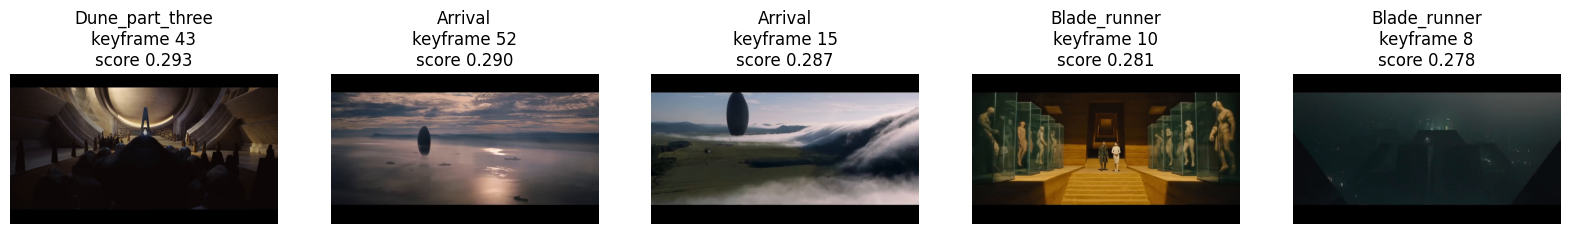

<class 'torch.Tensor'>
torch.Size([1, 512])
tensor([-0.0174,  0.0242, -0.0347,  0.0328, -0.0577,  0.0095, -0.0140, -0.0800,
         0.0184, -0.0045], device='cuda:0')


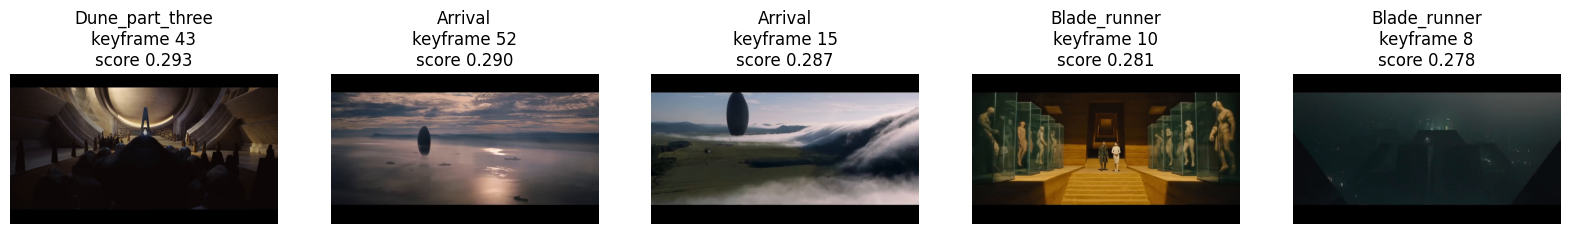

In [58]:
query = "a person standing in front of a giant alien structure"


results_no_limit = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=None
    )


results_max2 = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=2
 )

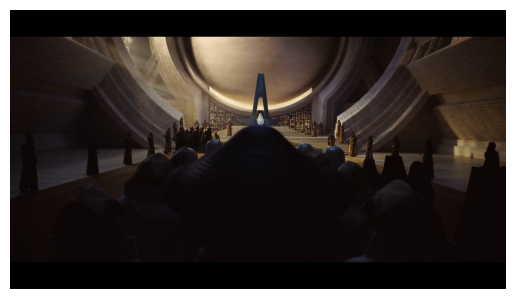

In [59]:
# 제일 스코어가 높은 이미지
target_path = image_paths_by_movie["Dune_part_three"][43]
img = Image.open(target_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [60]:
%cd /content/GroundingDINO


/content/GroundingDINO


In [63]:
%cd /content/GroundingDINO

import torch
from groundingdino.util.inference import load_model, load_image, predict, annotate
import cv2

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model = load_model(
    "groundingdino/config/GroundingDINO_SwinT_OGC.py",
    "weights/groundingdino_swint_ogc.pth",
    device=device
)

image_source, image = load_image(target_path)

text_prompt = "person . alien structure ."

boxes, logits, phrases = predict(
    model=model,
    image=image,
    caption=text_prompt,
    box_threshold=0.35,
    text_threshold=0.25,
    device=device
)

print(boxes)
print(logits)
print(phrases)

/content/GroundingDINO
device: cuda
final text_encoder_type: bert-base-uncased


RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory. This is an internal miniz error. If you are seeing this error, there is a high likelihood that your checkpoint file is corrupted. This can happen if the checkpoint was not saved properly, was transferred incorrectly, or the file was modified after saving.

### Query 1
---

**Text Query:** `a person standing in front of a giant alien structure`

**Result:** Partial

**Failure Type:** Relation Failure



**Reason:**
검색 결과 일부는 거대한 구조물이나 외계 물체와 관련된 장면을 포함했지만, 'person standing in front of'라는 구체적인 관계는 명확하게 반영되지 않았다. 따라서 CLIP은 구조물, 어두운 분위기, SF적 배경에는 반응했지만,
사람이 구조물 앞에 서 있다는 세부 관계까지는 정확히 구분하지 못한 것으로 볼 수 있다.


In [ ]:
import inspect
print(inspect.signature(search_text_scene))

In [ ]:
query = "a wide desert landscape with sand dunes"


results_no_limit = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=None
    )


results_max2 = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=2
    )

### Query 2
---

**Text Query:** `a wide desert landscape with sand dunes,`

**Result:** Partial

**Failure Type:** Context Bias



**Reason:**
검색 결과 중 일부는 사막과 모래언덕이 포함되어 있어 쿼리의 전체적인 배경은 어느 정도 반영되었다.
특히 Dune_part_three의 일부 키프레임은 사막 풍경과 유사하게 나타났다.

하지만 이후 결과에는 어두운 프레임이나 쿼리와 직접적인 관련이 낮은 장면도 함계 반환되었다.
이는 clip이 desert, sand dunes, iandscape 와 같은 장면 분위기에는 일부 반응했지만, 넓은 사막 풍경이라는 구체적인 시각 조건을 안정적으로 구분하지 못한 사례로 볼 수 있다.

따라서 해당 결과는 완전한 성공보다는 부분적으로만 의미가 맞는 Partial로 평가하였다.

In [ ]:
query = "a futuristic city street at night with neon lights"


results_no_limit = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=None
    )


results_max2 = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=2
)

### Query 3
---

**Text Query:** `a futuristic city street at night with neon lights,`

**Result:** Partial

**Failure Type:** Context Bias



**Reason:**
검색 결과는 neon, night, futuristic과 같은 분위기 요소에는 비교적 잘 반응하였다.
특히 제한을 두지 않았을 때는 Blade_runner 장면이 반복적으로 검색되며, 네온 조명과 어두운 미래 도시 분위기가 쿼리와 어느 정도 일치하였다.

하지만 쿼리에서 요구한 city street 구조가 모든 결과에서 명확하게 나타난 것은 아니었다.
일부 결과는 네온 색감이나 어두운 SF 분위기는 맞지만, 실제로 도시 거리 장면이라고 보기에는 애매했다.

max_per_movie=2를 적용한 경우에는 같은 영화의 반복 결과는 줄었지만, 대신 다른 영화의 어두운 장면이나 미래적인 분위기의 장면이 포함되었다.
이는 모델이 쿼리의 구체적인 장소인 city street보다 futuristic, night, neon과 같은 전체 분위기에 더 강하게 반응한 사례로 볼 수 있다.

따라서 해당 결과는 완전한 성공보다는 부분적으로 의미가 맞는 Partial로 평가하였다.

In [ ]:
query = "a spaceship flying in outer space"


results_no_limit = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=None
    )


results_max2 = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=2
    )

### Query 4
---

**Text Query:** `a spaceship flying in outer space`

**Result:** Partial

**Failure Type:** Object Failure

**Reason:**  
검색 결과 일부는 우주선이나 우주 공간과 관련된 장면을 포함하고 있어, 쿼리의 전체적인 SF 문맥은 어느 정도 반영되었다.  
특히 `max_per_movie=None`일 때는 우주선 외부 장면과 우주선 내부 장면이 함께 검색되어, 텍스트와 부분적으로 일치하는 결과를 보여주었다.

하지만 많은 결과가 우주선 자체보다는 조종석 내부, 우주복을 입은 인물, 또는 우주선 내부 상황에 집중되어 있었다.  
즉, 모델은 `outer space`라는 배경 문맥에는 반응했지만, 쿼리의 핵심 객체인 `spaceship` 자체를 일관되게 찾지는 못했다.

`max_per_movie=2`를 적용한 경우에는 같은 영화의 반복 결과는 줄었지만, 대신 다른 영화의 우주·SF 분위기 장면이 포함되었다.  
이는 모델이 쿼리의 핵심 객체보다는 장면의 전체적인 우주적 분위기와 문맥에 더 강하게 반응한 것으로 해석할 수 있다.

따라서 이 결과는 완전한 성공보다는 부분적으로만 의미가 맞는 `Partial`로 평가하였다.



In [ ]:
query = "a close-up shot of a serious human face"


results_no_limit = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=None
    )


results_max2 = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=2
    )

### Query 5
---

**Text Query:** `a close-up shot of a serious human face`

**Result:** Partial

**Failure Type:**  Object Failure

**Reason:**  
검색 결과는 전반적으로 `close-up shot`과 `human face`라는 요소에는 어느 정도 반응하였다.  
특히 2~4번째 결과는 사람 얼굴의 클로즈업 장면으로, 쿼리와 부분적으로 일치한다고 볼 수 있다.

하지만 1번째 결과는 얼굴 전체가 아니라 눈만 크게 나타나 있어 `human face`라는 핵심 객체를 완전히 만족하지 못했고,  
5번째 결과는 검은 화면으로 쿼리와 직접적인 관련성이 거의 없었다.

즉, 모델은 얼굴 클로즈업이라는 전반적인 시각적 특징에는 반응했지만,  
쿼리의 핵심 객체인 `serious human face`를 일관되게 정확히 찾지는 못했다.

따라서 해당 결과는 완전한 성공보다는 부분적으로만 의미가 맞는 `Partial`로 평가하였다.




In [ ]:
query =  "a dark room with blue lighting"




results_no_limit = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=None
    )


results_max2 = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=2
    )

### Query 6
---

**Text Query:** `a dark room with blue lighting`

**Result:** Partial

**Failure Type:**  Context Bias

**Reason:**
검색 결과는 전반적으로 `dark`와 `blue lighting`이라는 분위기 요소에는 비교적 잘 반응하였다.  
일부 장면은 실제로 어두운 실내 공간과 푸른 조명을 포함하고 있어, 쿼리와 부분적으로 일치하였다.

그러나 모든 결과가 `room`이라는 공간 정보를 명확하게 보여주지는 않았으며,  
일부 장면은 단순히 어두운 분위기나 푸른 색감만 유사할 뿐 실내 공간이라고 보기에는 애매하였다.  
즉, 모델은 쿼리의 구체적인 장면 구성보다는 전체적인 색감과 분위기에 더 강하게 반응한 것으로 보인다.


`max_per_movie=None`인 경우에는 `dark`와 `room` 요소에 더 가까운 장면들이 반복적으로 검색되었고,  
`max_per_movie=2`를 적용한 경우에는 다양한 영화에서 어두운 분위기와 푸른 조명을 가진 장면들이 포함되었다.  
하지만 두 경우 모두 `blue lighting`의 정확한 조건보다는 전반적인 시각적 분위기에 의존하는 경향이 나타났다.

따라서 이 결과는 완전한 성공이라기보다는, 분위기와 일부 요소만 맞는 `Partial`로 평가하였다.



In [ ]:

query =   "a bright light shining behind a silhouette"
results_no_limit = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=None
    )


results_max2 = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=2
    )

### Query 7

---

**Text Query:** `a  bright light shining behind a silhouette`

**Result:**  Fail

**Failure Type:**  Context Bias

**Reason:**
검색 결과는 전반적으로 강한 빛과 어두운 배경처럼 쿼리의 분위기 요소에는 일부 반응하였다.  
그러나 대부분의 결과에서 `silhouette`가 명확하게 나타나지 않았고,  
`bright light shining behind`라는 관계 또한 분명하게 드러나지 않았다.

따라서 이 결과는 완전한 성공이나 부분 성공보다는 `Fail`로 평가하였다.


# 대표 쿼리 분석

| 대표 쿼리                                           | 대표 실패 유형                       | 고른 이유                    |
| ----------------------------------------------- | ------------------------------ | ------------------------ |
| `a bright light shining behind a silhouette`    | Relation Bias / Object Missing | 객체와 위치 관계 실패를 가장 잘 보여줌   |
| `a dark room with blue lighting`                | Context Bias                   | 분위기에는 반응하지만 세부 조건이 약한 사례 |
| `a person walking alone in a large empty space` | Action Bias                    | 정지 이미지에서 행동 판단이 어려운 사례   |


In [ ]:
import pandas as pd
from IPython.display import display

evaluation_data = [
    {
        "Query ID": "Query 1",
        "Text Query": "a person standing in front of a giant alien structure",
        "max_movies": 2,
        "Result": "Partial",
        "Failure Type": "Relation Bias",
        "Reason": "거대한 구조물이나 외계적인 장면은 일부 반영되었지만, 사람이 구조물 앞에 서 있다는 공간 관계가 명확하지 않았다."
    },
    {
        "Query ID": "Query 1",
        "Text Query": "a person standing in front of a giant alien structure",
        "max_movies": None,
        "Result": "Partial",
        "Failure Type": "Context Bias",
        "Reason": "외계적 분위기나 거대한 구조물 중심으로 결과가 몰렸지만, 사람과 구조물의 관계는 불안정하게 나타났다."
    },

    {
        "Query ID": "Query 2",
        "Text Query": "a wide desert landscape with sand dunes",
        "max_movies": 2,
        "Result": "Partial",
        "Failure Type": "Scene Bias",
        "Reason": "넓은 풍경이나 황량한 분위기는 일부 반영되었지만, sand dunes가 명확하게 나타나지 않았다."
    },
    {
        "Query ID": "Query 2",
        "Text Query": "a wide desert landscape with sand dunes",
        "max_movies": None,
        "Result": "Partial",
        "Failure Type": "Context Bias",
        "Reason": "사막과 유사한 색감이나 분위기에 반응했지만, 모래언덕이라는 구체적인 장면 조건은 약하게 반영되었다."
    },

    {
        "Query ID": "Query 3",
        "Text Query": "a futuristic city street at night with neon lights",
        "max_movies": 2,
        "Result": "Partial",
        "Failure Type": "Context Bias",
        "Reason": "밤, 도시, 네온 분위기는 일부 반영되었지만, futuristic city street라는 구체적인 공간은 완전하지 않았다."
    },
    {
        "Query ID": "Query 3",
        "Text Query": "a futuristic city street at night with neon lights",
        "max_movies": None,
        "Result": "Partial",
        "Failure Type": "Context Bias",
        "Reason": "네온과 어두운 분위기에 결과가 몰렸지만, 실제 도시 거리 장면과는 차이가 있었다."
    },

    {
        "Query ID": "Query 4",
        "Text Query": "a dark room with blue lighting",
        "max_movies": 2,
        "Result": "Partial",
        "Failure Type": "Context Bias",
        "Reason": "어두운 방과 푸른 색감은 일부 반영되었지만, blue lighting이 직접적으로 드러나는 장면은 제한적이었다."
    },
    {
        "Query ID": "Query 4",
        "Text Query": "a dark room with blue lighting",
        "max_movies": None,
        "Result": "Partial",
        "Failure Type": "Context Bias",
        "Reason": "dark room 요소에 강하게 반응했지만, blue lighting보다 어두운 분위기 중심으로 검색되었다."
    },

    {
        "Query ID": "Query 5",
        "Text Query": "a person walking alone in a large empty space",
        "max_movies": 2,
        "Result": "Partial",
        "Failure Type": "Action Bias",
        "Reason": "넓고 비어 있는 공간은 일부 반영되었지만, 사람이 혼자 걷는 행동은 명확하지 않았다."
    },
    {
        "Query ID": "Query 5",
        "Text Query": "a person walking alone in a large empty space",
        "max_movies": None,
        "Result": "Partial",
        "Failure Type": "Action Bias",
        "Reason": "공간적 분위기는 반영되었지만, walking이라는 행동 조건보다는 전체 장면 분위기에 더 반응하였다."
    },

    {
        "Query ID": "Query 6",
        "Text Query": "a close-up of a mysterious face in the dark",
        "max_movies": 2,
        "Result": "Partial",
        "Failure Type": "Object Bias",
        "Reason": "얼굴이나 어두운 분위기는 일부 반영되었지만, close-up과 mysterious face 조건이 항상 명확하지 않았다."
    },
    {
        "Query ID": "Query 6",
        "Text Query": "a close-up of a mysterious face in the dark",
        "max_movies": None,
        "Result": "Partial",
        "Failure Type": "Context Bias",
        "Reason": "어두운 분위기에 결과가 몰렸지만, 얼굴 클로즈업이라는 핵심 객체 조건은 불안정하게 나타났다."
    },

    {
        "Query ID": "Query 7",
        "Text Query": "a bright light shining behind a silhouette",
        "max_movies": 2,
        "Result": "Fail",
        "Failure Type": "Relation Bias / Object Missing",
        "Reason": "강한 빛과 어두운 분위기는 일부 반영되었지만, silhouette와 behind 관계가 명확하지 않았다."
    },
    {
        "Query ID": "Query 7",
        "Text Query": "a bright light shining behind a silhouette",
        "max_movies": None,
        "Result": "Fail",
        "Failure Type": "Context Bias",
        "Reason": "밝은 빛과 어두운 배경에는 반응했지만, silhouette 객체와 bright light shining behind 관계는 제대로 나타나지 않았다."
    },
]

df_eval = pd.DataFrame(evaluation_data)

display(df_eval)

In [ ]:
robot_problem_map = {
    "Context Bias": "환경 분위기나 조명에 치우쳐 목표 객체 또는 세부 조건 인식이 흔들림",
    "Relation Bias": "객체 간 위치 관계 인식 실패",
    "Relation Bias / Object Missing": "객체 존재 여부와 위치 관계 인식 실패",
    "Object Bias": "목표 객체를 안정적으로 구분하지 못함",
    "Object Missing": "목표 객체 탐지 실패",
    "Action Bias": "사람 또는 객체의 상태/행동 판단 실패",
    "Scene Bias": "큰 장면 범주는 인식하지만 세부 환경 구조 이해가 부족함"
}

df_eval["Robot Perception 문제"] = df_eval["Failure Type"].map(robot_problem_map)

display(df_eval)

In [ ]:
from IPython.display import Markdown, display

markdown_table = df_eval.to_markdown(index=False)

display(Markdown(markdown_table))

# GroundingDINO

In [ ]:
query =   "a futuristic city street with people, cars, buildings, and lights"
results_no_limit = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=None
    )


results_max2 = search_text_scene(
                    text_query=query,
                    index_ip= index_ip,
                    metadata= metadata,
                    model=model,
                    processor= processor,
                    device= device,
                    all_image_paths=all_image_paths,
                    k=5,
                    search_k=30,
                    max_per_movie=2
    )